# Sleep Health Factor Analysis
## Background and Problem Definition:
Sleep is essential for maintaining good health and well-being. It plays a vital role in one's physical, mental, and emotional health. Even so, many people (including myself) struggle falling asleep, staying asleep, and getting good quality sleep. In an attempt to combat this worldwide problem, I will be analyzing what factors are the most beneficial and detrimental for getting an adequate amount of high quality sleep. There are many variables used in the analysis. These variables are gender of the person, age of the person, hours of sleep, quality of sleep (1-5), level of stress (1-5), blood pressure, heart rate, daily steps taken, amount of physical activity in minutes, height, weight, and average screen time in minutes. Other variables include whether or not the individual wakes up over night, consumes caffeine, consumes alcohol, smokes, uses a smart device before bed, and uses a blue light filter. These variables are all listed as "Y" for yes and "N" for no. Hopefully the conclusion of this analysis can inform myself and others what they can do to get better sleep. I will also try to create a predictive model on sleep duration and quality. This data set is from Kaggle.

Link to Dataset: https://www.kaggle.com/datasets/arifmia/sleep-health-and-digital-screen-exposure-dataset/data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Wrangling
First and foremost, let's load in and take a look at the format of the data.

In [ ]:
df = pd.read_csv("SleepData.csv")
df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y


As shown, this dataset has 26 total columns, including 10 columns holding dbl values and 16 columns holding char values.

The purpose of this analysis is to inform the general population what factors increase/decrease sleep time and quality. As a result, we will remove all the entries of people with sleep disorders and medical issues since only about 15% of the general population struggles with a sleep disorder. This is especially important because over 50% of entries in this dataset are those with sleep disorders and this would skew our data and analysis.


In [ ]:
df.rename(columns={"Sleep disorder": "SleepDisorder", "Medical issue": "MedicalIssue"}, inplace=True)
df = df[(df["SleepDisorder"] != "Y") & (df["MedicalIssue"] != "Y")]

Now we can clean up our dataset by getting rid of those 2 columns since every entry will hold the same value. We can also get rid of several other columns. Including but not limited to, many eye conditions since they will not be applicable for this analysis. We will also rename several columns that have spaces in their title to maintain consistency and avoid future difficulties.

In [ ]:
df = df.drop(df.columns[[11,17,18,22,23,24,25]], axis=1)
df = df.reset_index(drop=True)
df.rename(columns={
    "Sleep duration": "SleepDuration",
    "Sleep quality": "SleepQuality",
    "Stress level": "StressLevel",
    "Blood pressure": "BloodPressure",
    "Heart rate": "HeartRate",
    "Daily steps": "DailySteps",
    "Physical activity": "PhysicalActivity",
    "Wake up during night": "WakeUpOverNight",
    "Feel sleepy during day": "FeelSleepyDuringDay",
    "Caffeine consumption": "CaffeineConsumption",
    "Alcohol consumption": "AlcoholConsumption",
    "Smart device before bed": "SmartDeviceBeforeBed",
    "Average screen time": "AvgScreenTime",
    "Blue-light filter": "BlueLightFilter"
    }, inplace=True)

Categorical variables must also be changed to factors to ensure python correctly interprets these categorical variables when applying algorithms.

In [ ]:
cols_to_convert = ["WakeUpOverNight", "CaffeineConsumption", "AlcoholConsumption", "Smoking", "SmartDeviceBeforeBed", "BlueLightFilter", "FeelSleepyDuringDay"]

for col in cols_to_convert:
    df[col] = df[col].map({'Y': 1, 'N': 0})
df["Gender"] = df["Gender"].map({'M': 1, 'F': 0})



In [ ]:
df.head()

,Gender,Age,SleepDuration,SleepQuality,StressLevel,BloodPressure,HeartRate,DailySteps,PhysicalActivity,Height,Weight,WakeUpOverNight,FeelSleepyDuringDay,CaffeineConsumption,AlcoholConsumption,Smoking,SmartDeviceBeforeBed,AvgScreenTime,BlueLightFilter
0,1,33,5.5,2,1,109/85,97,5000,71,162,91,0,0,0,1,0,0,4.5,1
1,0,21,8.8,4,5,131/65,78,5000,125,170,91,1,0,1,0,0,1,7.9,1
2,0,19,4.6,4,5,132/66,100,17000,90,188,54,1,0,0,0,1,0,7.7,0
3,0,19,9.5,3,5,130/87,81,6000,175,188,79,1,1,1,0,1,1,8.2,0
4,0,32,8.0,4,2,120/86,62,1000,90,193,51,1,1,1,1,0,0,6.3,0


We now have a table that is much easier to read and handle.
Finally, we will ensure data integrity by checking for null values and duplicate entries.

In [ ]:
print("Number of Null Values By Column:")
print(df.isnull().sum())
print("Number of Duplicate Values:")
print(df.duplicated().sum())

Number of Null Values By Column:
Gender                  0
Age                     0
SleepDuration           0
SleepQuality            0
StressLevel             0
BloodPressure           0
HeartRate               0
DailySteps              0
PhysicalActivity        0
Height                  0
Weight                  0
WakeUpOverNight         0
FeelSleepyDuringDay     0
CaffeineConsumption     0
AlcoholConsumption      0
Smoking                 0
SmartDeviceBeforeBed    0
AvgScreenTime           0
BlueLightFilter         0
dtype: int64
Number of Duplicate Values:
0


After verifying that there are no null values or duplicate entries, our data wrangling and cleaning is complete.

## Exploratory Analysis
First, we will familiarize ourselvelves with the data further by visualizing the distribution of sleep duration and sleep quality.

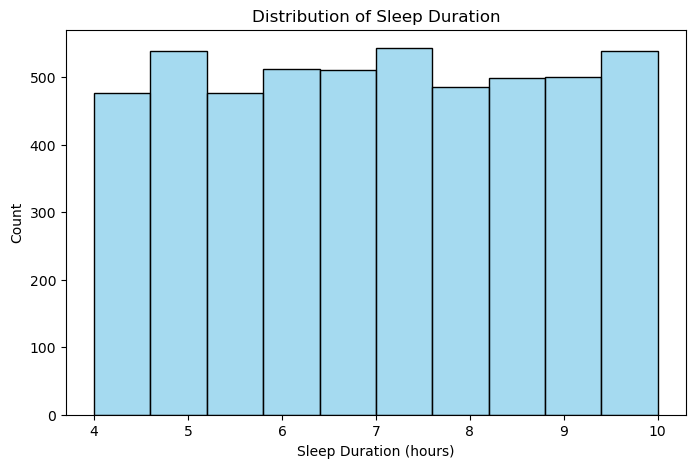

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["SleepDuration"], bins=10, color="skyblue")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Count")
plt.title("Distribution of Sleep Duration")
plt.show()

From this histogram we can see that the distribution of sleep duration is somewhat even across the board. However, there are many people getting less than the recommended 7-9 hours of sleep per night. Making this a very relevant issue.

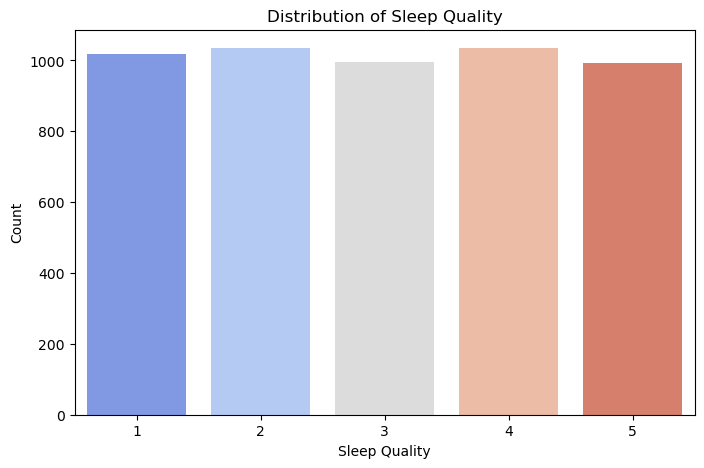

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["SleepQuality"], palette="coolwarm")
plt.xlabel("Sleep Quality")
plt.ylabel("Count")
plt.title("Distribution of Sleep Quality")
plt.show()

The distribution of sleep quality is very similar to sleep duration. In the way that it is relatively equal across all 5 levels and there are a lot of people getting below average sleep quality.

### Linear Regression
We will now attempt to find relationships between sleep duration/quality and the various factors through linear regression modeling.

In [ ]:
X = df[["StressLevel", "HeartRate", "DailySteps", "PhysicalActivity",
        "Height", "Weight", "CaffeineConsumption", "AlcoholConsumption",
        "Smoking", "SmartDeviceBeforeBed", "BlueLightFilter"]]
X = pd.get_dummies(X, drop_first=True)
X = sm.add_constant(X)
y = df["SleepDuration"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          SleepDuration   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.368
Date:                Sun, 02 Mar 2025   Prob (F-statistic):              0.180
Time:                        22:02:12   Log-Likelihood:                -9997.4
No. Observations:                5078   AIC:                         2.002e+04
Df Residuals:                    5066   BIC:                         2.010e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    7.0646 

The result is a lot of information and can seem overwhelming but we will mainly be focusing on the p-values and coefficients. This is because p-values show the statistical significance of the factor and the coefficients show how much that factor affects sleep duration.

Looking at the p-values, almost all of them are higher than the 0.05 value that indicates statistical significance. In fact, the only one with a p-value lower than 0.05 is heart rate, suggesting this an important factor in sleep duration.

Let's take a look at the graph for sleep duration based on heart rate.

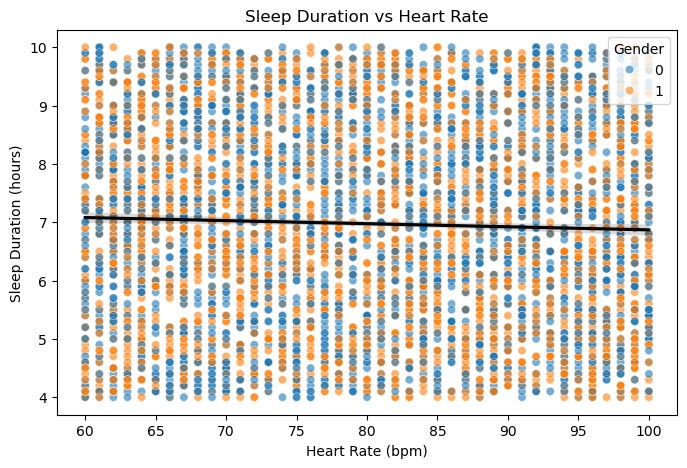

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["HeartRate"], y=df["SleepDuration"], hue=df["Gender"], alpha=0.6)
sns.regplot(x=df["HeartRate"], y=df["SleepDuration"], scatter=False, color="black")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Sleep Duration (hours)")
plt.title("Sleep Duration vs Heart Rate")
plt.show()

With the amount of data we have, it is difficult to see any correlation between the points. However, we can see that heart rate has a slight negative effect on sleep duration from the regression line.

The p-values of stress level, alcohol consumption, and use of a blue light filter are comparatively low but still not low enough to prompt that they are statistically significant.

Looking at the coefficients, we can see that the coefficients of stress level, heart rate, caffeine consumption, alcohol consumption, smoking, using a smart device, and using a blue light filter are relatively higher than the other variables. This suggests that these factors make more of a difference in how long you sleep, although it is still a subtle difference as these values are still small.

However, you can also see in the summary that our R-squared value is very low. This suggests that our linear regression model does not explain much of the variation in the length of one's sleep. So all the inferences made from this model should be taken with a grain of salt.

Hopefully we'll have better results when analyzing sleep quality.

In [ ]:
y = df['SleepQuality']
model_sleep_quality = sm.OLS(y, X).fit()
print(model_sleep_quality.summary())

                            OLS Regression Results                            
Dep. Variable:           SleepQuality   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.077
Date:                Sun, 02 Mar 2025   Prob (F-statistic):              0.375
Time:                        22:02:13   Log-Likelihood:                -8950.5
No. Observations:                5078   AIC:                         1.792e+04
Df Residuals:                    5066   BIC:                         1.800e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.8603 

This time we see that there are no p-values under 0.05, indicating that none of these variables impact sleep quality.

However, we see the same variables with higher coefficients as we did in the sleep duration model. So maybe we are onto something.

Unfortunately, our R-squared value is once again very low. Maybe we need to try a different approach.

### Random Forest
We will now try using the random forest approach as it is more capable of handling complex interactions and is less sensitive to overfitting than our linear regression model. We will use the random forest model to not only find which factors influence sleep the most, but also create a predictive model for both sleep duration and quality.

In [ ]:
rf = RandomForestRegressor(n_estimators=500, random_state=77)
X= df[['StressLevel', 'HeartRate', 'DailySteps', 'PhysicalActivity',
                'Height', 'Weight', 'CaffeineConsumption', 'AlcoholConsumption',
                'Smoking', 'SmartDeviceBeforeBed', 'BlueLightFilter']]
y = df['SleepDuration']
rf.fit(X, y)
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

Mean Squared Error for Sleep Duration: 0.43


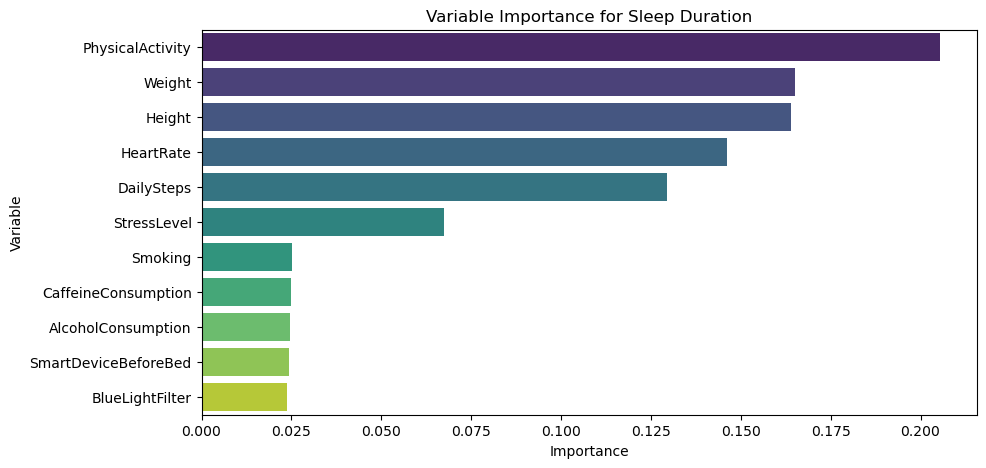

In [ ]:
y_pred = rf.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error for Sleep Duration: {mse:.2f}")
plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Variable Importance for Sleep Duration")
plt.show()

Please note, I included each variable on the y-axis instead of the x-axis to ensure readability of the variable names. When variable names were on the x-axis, they overlapped each other, reducing the readability of the graph.
The random forest model for sleep duration had a Mean Squared Error of 0.43. This is around 30 minutes, a small amount of error compared to the 10 possible hours, suggesting that this model can be used to predict sleep duration. The plot above also shows that physical activity, weight, height, heart rate, daily steps, and stress level all hold higher importance when predicting sleep duration than the other variables.

Mean Squared Error for Sleep Quality Model: 0.29


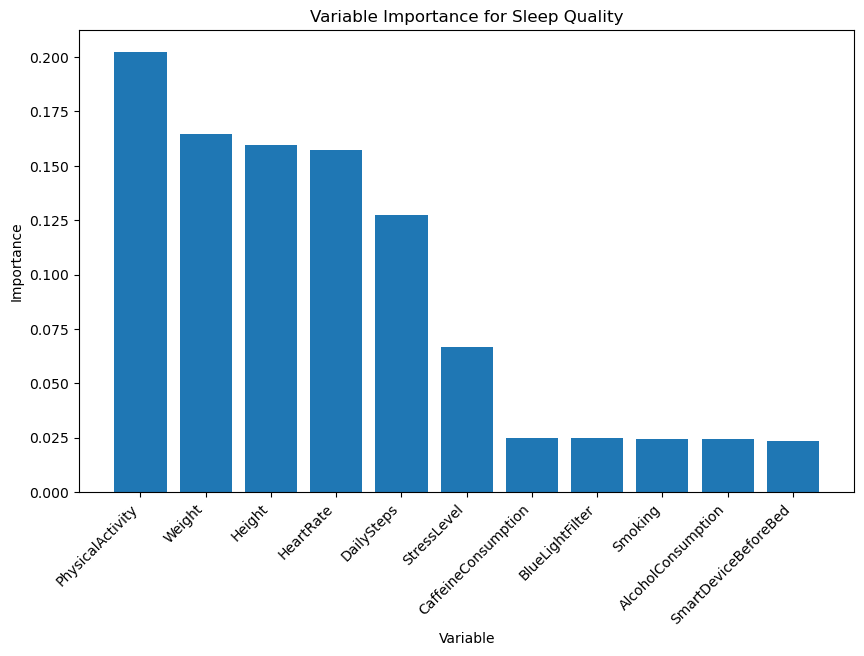

In [ ]:
X= df[['StressLevel', 'HeartRate', 'DailySteps', 'PhysicalActivity',
                'Height', 'Weight', 'CaffeineConsumption', 'AlcoholConsumption',
                'Smoking', 'SmartDeviceBeforeBed', 'BlueLightFilter']]
y_quality = df['SleepQuality']
rf_sleep_quality = RandomForestRegressor(n_estimators=500, random_state=77)
rf_sleep_quality.fit(X, y_quality)
y_pred_quality = rf_sleep_quality.predict(X)
mse_quality = mean_squared_error(y_quality, y_pred_quality)
print(f"Mean Squared Error for Sleep Quality Model: {mse_quality:.2f}")
importances_quality = rf_sleep_quality.feature_importances_
feature_names = X.columns
indices = np.argsort(importances_quality)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Variable Importance for Sleep Quality")
plt.bar(range(len(importances_quality)), importances_quality[indices], align="center")
plt.xticks(range(len(importances_quality)), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.xlabel("Variable")
plt.ylabel("Importance")
plt.show()


The random forest model for sleep quality had a Mean Squared Error of 0.29. On a scale from 1-5 this is a relatively small amount of error, suggesting that this model can be used to predict sleep quality. The plot above also shows that physical activity, weight, height, heart rate, daily steps, and stress level all hold higher importance when predicting sleep quality than the other variables. This is very similar to the results that our sleep duration variable importance plot gave.

## Conclusion
All in all, there are many different factors that impact sleep duration and sleep quality. Our linear regression model was not very succesful in determining which factors are significant as it only identified heart rate as being significant for sleep duration. This model also had a very low R squared value which suggests that it is not very accurate. On the other hand, our new random forest model was able to identify and rank the factors that impact sleep duration/quality by importance. These factors were physical activity, weight, height, heart rate, daily steps, and stress level. The random forest model was also able to make predictions on sleep duration/quality quite accurately with low mean squared error. In the end, Random Forests was a much better approach to identify key factors and estimate sleep duration and quality. From this analysis, to improve your sleep duration and quality, one should attempt to increase their amount of physical activity and daily steps while trying to reduce their weight, heart rate, and stress level.
